## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import mean_squared_error, mean_absolute_error

## Parameters

In [2]:
roll = "102317161"

digits = [int(d) for d in roll]

window_size = sum(digits) % 10 + 8
prediction_horizon = int(roll[-2:]) % 3 + 1
hidden_size = int(roll[:3]) % 16 + 8

print('window size :',window_size)
print('prediction horizon :',prediction_horizon)
print('hidden size :',hidden_size)

window size : 10
prediction horizon : 2
hidden size : 14


## Windowing Function

In [3]:
def create_sequences(data, window_size, horizon):
    """
    Convert time-series into supervised learning format
    X = past values
    y = future values
    """
    X, y = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size:i+window_size+horizon])

    return np.array(X), np.array(y)

## Model Definitions

In [4]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(window_size, 64),
            nn.ReLU(),
            nn.Linear(64, prediction_horizon)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

## Custom GRU

In [5]:
# GRU uses update and reset gates to control memory flow over time
class CustomGRU(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_size = hidden_size

        self.Wz = nn.Linear(1 + hidden_size, hidden_size)
        self.Wr = nn.Linear(1 + hidden_size, hidden_size)
        self.Wh = nn.Linear(1 + hidden_size, hidden_size)

        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()

        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(seq_len):
            xt = x[:, t, :]
            combined = torch.cat((xt, h), dim=1)

            z = torch.sigmoid(self.Wz(combined))
            r = torch.sigmoid(self.Wr(combined))

            combined_reset = torch.cat((xt, r * h), dim=1)
            h_tilde = torch.tanh(self.Wh(combined_reset))

            h = (1 - z) * h + z * h_tilde

        return self.fc(h)

## LSTM

In [6]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, prediction_horizon)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

## TRANSFORMER

In [7]:
class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Linear(1, 16)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=16,
            nhead=2,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.fc = nn.Linear(16, prediction_horizon)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.fc(x[:, -1, :])

## Train Function

In [8]:
def train_model(model, loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0

        for xb, yb in loader:
            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 2 == 0:
            print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

## Evaluation Function

In [9]:
def evaluate(model, X_test, y_test):
    preds = model(X_test).detach().numpy()
    true = y_test.detach().numpy()

    mse = mean_squared_error(true, preds)
    mae = mean_absolute_error(true, preds)
    rmse = np.sqrt(mse)

    return mse, mae, rmse, preds, true

## Pipeline

In [10]:
def run_pipeline(data, name):
    print(f"\n===== {name} =====")

    # Create sequences
    X, y = create_sequences(data, window_size, prediction_horizon)

    print("Sample Input:", X[0])
    print("Sample Output:", y[0])

    # Chronological split
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Convert to tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)

    # input shape (only if needed)
    if len(X_train.shape) == 4:
        X_train = X_train.squeeze(-1)
        X_test = X_test.squeeze(-1)

    if len(X_train.shape) == 2:
        X_train = X_train.unsqueeze(-1)
        X_test = X_test.unsqueeze(-1)

    print("Final Input Shape:", X_train.shape)

    # target shape
    y_train = torch.tensor(y_train, dtype=torch.float32).squeeze(-1)
    y_test = torch.tensor(y_test, dtype=torch.float32).squeeze(-1)

    # DataLoader
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32)

    # Models
    models = {
        "MLP": MLP(),
        "GRU": CustomGRU(),
        "LSTM": LSTMModel(),
        "Transformer": TransformerModel()
    }

    # Train and evaluate
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")

        train_model(model, loader)

        mse, mae, rmse, preds, true = evaluate(model, X_test, y_test)

        print(f"{model_name}: MSE={mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")

        plt.figure(figsize=(8,5))

        plt.plot(true[:100, 0], label="Actual")
        plt.plot(preds[:100, 0], label="Predicted")

        plt.title(f"{model_name} - {name}")
        plt.legend()
        plt.show()

## Dataset 1

/tmp/ipykernel_2331/2838364095.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Text(0.5, 1.0, 'Stock Data')

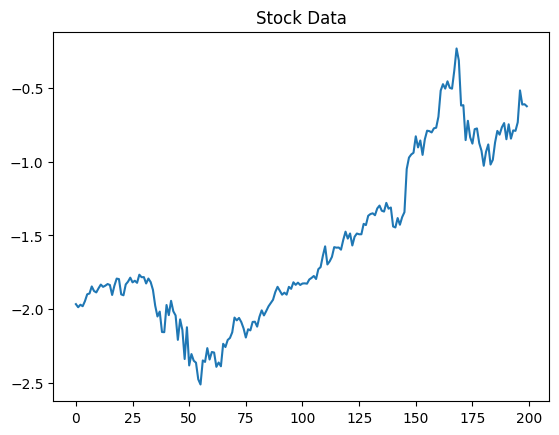

In [11]:
import yfinance as yf

df_stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

data_stock = df_stock['Close'].values
data_stock = (data_stock - data_stock.mean()) / data_stock.std()

plt.plot(data_stock[:200])
plt.title("Stock Data")

## Dataset 2

Text(0.5, 1.0, 'Temperature Data')

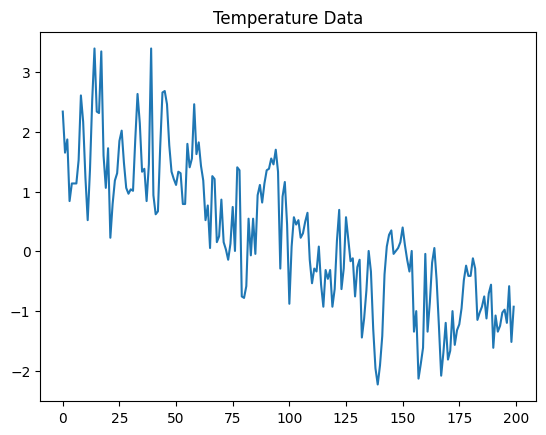

In [13]:
df_temp = pd.read_csv("/content/daily-min-temperatures.csv")

data_temp = df_temp['Temp'].values
data_temp = (data_temp - data_temp.mean()) / data_temp.std()

plt.plot(data_temp[:200])
plt.title("Temperature Data")

## Running Both Datsets


===== Stock Data =====
Sample Input: [[-1.96625743]
 [-1.98736928]
 [-1.97023422]
 [-1.98042826]
 [-1.94572428]
 [-1.89916428]
 [-1.89410262]
 [-1.84616943]
 [-1.87711309]
 [-1.88680119]]
Sample Output: [[-1.85860438]
 [-1.8333718 ]]
Final Input Shape: torch.Size([796, 10, 1])

Training MLP...
Epoch 0, Loss: 23.6003
Epoch 2, Loss: 5.5006
Epoch 4, Loss: 0.7536
Epoch 6, Loss: 0.6254
Epoch 8, Loss: 0.5723
MLP: MSE=0.0229, MAE=0.1275, RMSE=0.1514


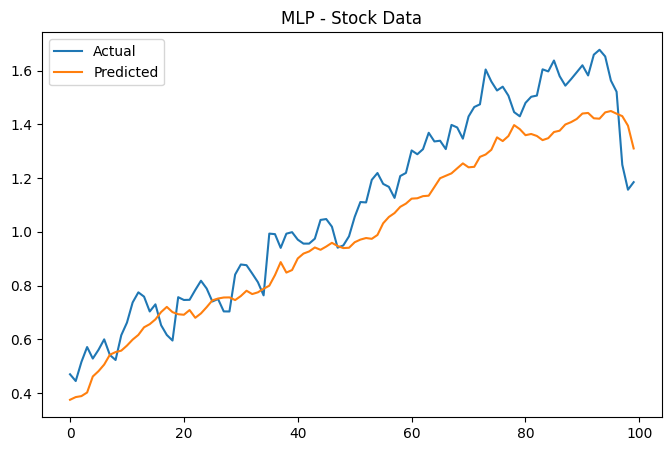


Training GRU...
Epoch 0, Loss: 18.1430
Epoch 2, Loss: 14.3575
Epoch 4, Loss: 9.9712
Epoch 6, Loss: 4.8763
Epoch 8, Loss: 1.9413
GRU: MSE=0.1942, MAE=0.3846, RMSE=0.4407


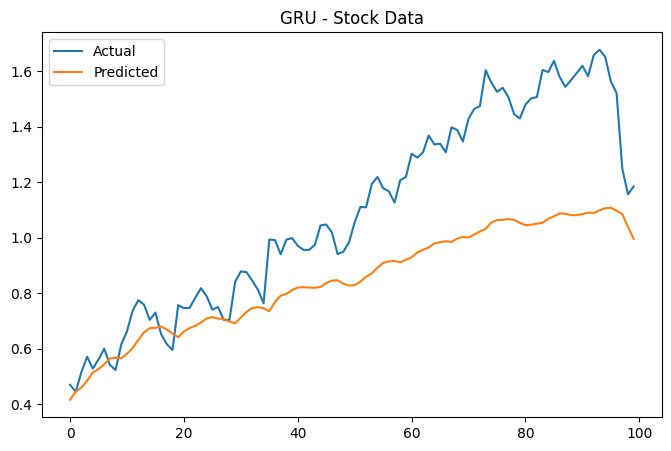


Training LSTM...
Epoch 0, Loss: 21.4385
Epoch 2, Loss: 17.8232
Epoch 4, Loss: 12.3924
Epoch 6, Loss: 6.0220
Epoch 8, Loss: 3.4697
LSTM: MSE=0.6042, MAE=0.7206, RMSE=0.7773


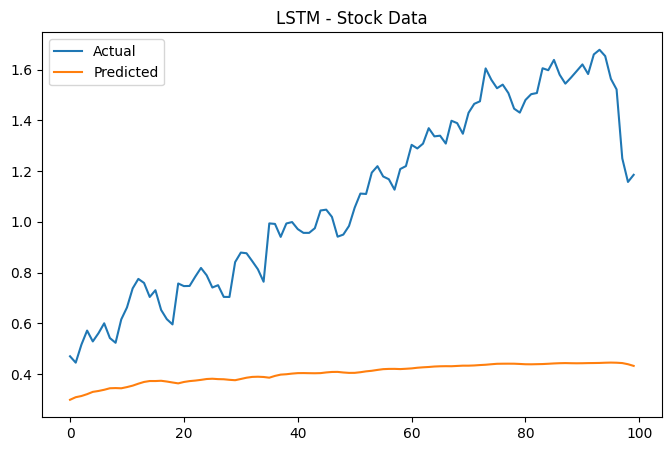


Training Transformer...
Epoch 0, Loss: 10.8251
Epoch 2, Loss: 7.7776
Epoch 4, Loss: 3.6986
Epoch 6, Loss: 2.0953
Epoch 8, Loss: 1.5300
Transformer: MSE=0.1100, MAE=0.2603, RMSE=0.3316


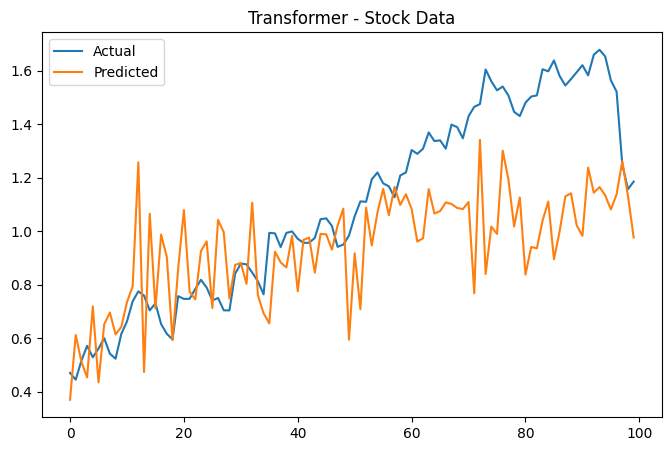

In [14]:
run_pipeline(data_stock, "Stock Data")


===== Temperature Data =====
Sample Input: [2.33888328 1.65113873 1.87219948 0.84058266 1.13533032 1.13533032
 1.13533032 1.52832721 2.60906864 2.16694715]
Sample Output: [1.23357954 0.52127269]
Final Input Shape: torch.Size([2911, 10, 1])

Training MLP...
Epoch 0, Loss: 60.0789
Epoch 2, Loss: 41.3405
Epoch 4, Loss: 39.7792
Epoch 6, Loss: 39.2423
Epoch 8, Loss: 38.9710
MLP: MSE=0.3570, MAE=0.4667, RMSE=0.5975


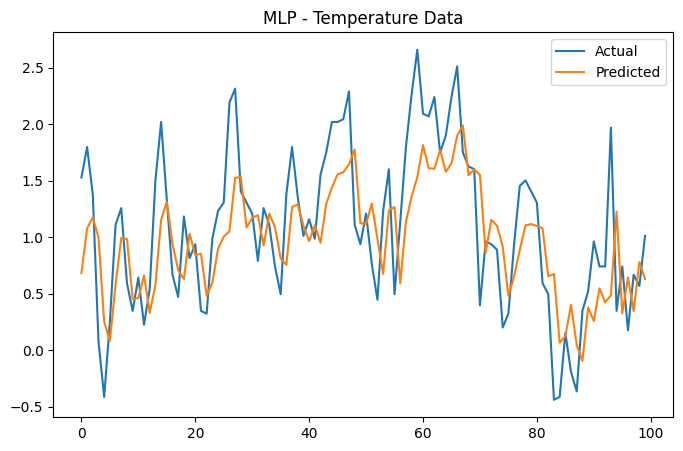


Training GRU...
Epoch 0, Loss: 95.9248
Epoch 2, Loss: 47.7206
Epoch 4, Loss: 43.1917
Epoch 6, Loss: 42.4202
Epoch 8, Loss: 41.7727
GRU: MSE=0.3796, MAE=0.4809, RMSE=0.6161


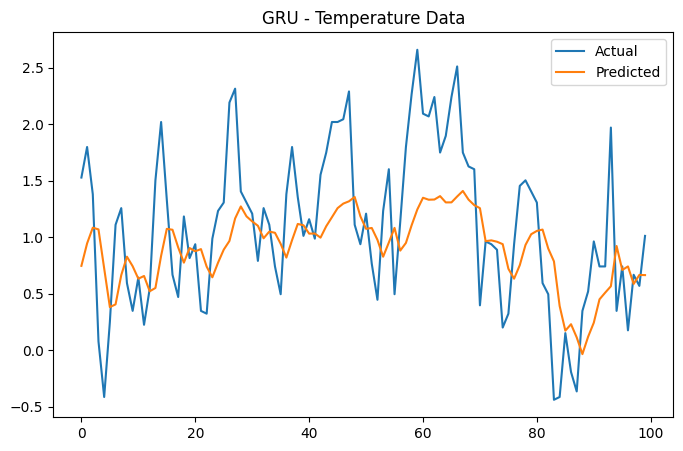


Training LSTM...
Epoch 0, Loss: 88.4280
Epoch 2, Loss: 46.8471
Epoch 4, Loss: 44.2146
Epoch 6, Loss: 43.3571
Epoch 8, Loss: 42.7916
LSTM: MSE=0.3911, MAE=0.4872, RMSE=0.6254


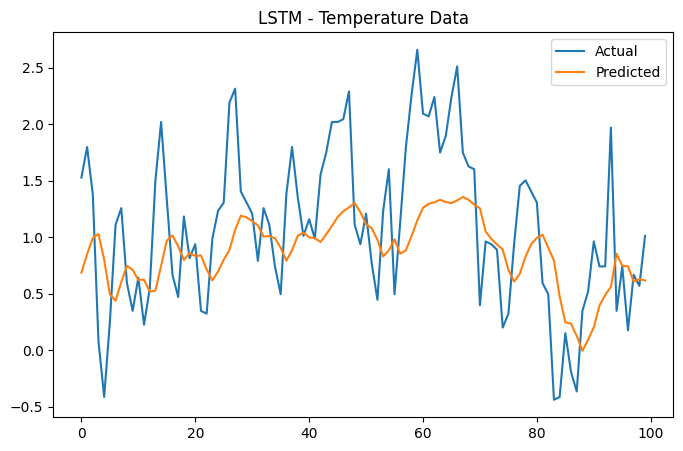


Training Transformer...
Epoch 0, Loss: 63.8257
Epoch 2, Loss: 43.0744
Epoch 4, Loss: 41.8473
Epoch 6, Loss: 41.8911
Epoch 8, Loss: 41.1147
Transformer: MSE=0.3616, MAE=0.4693, RMSE=0.6013


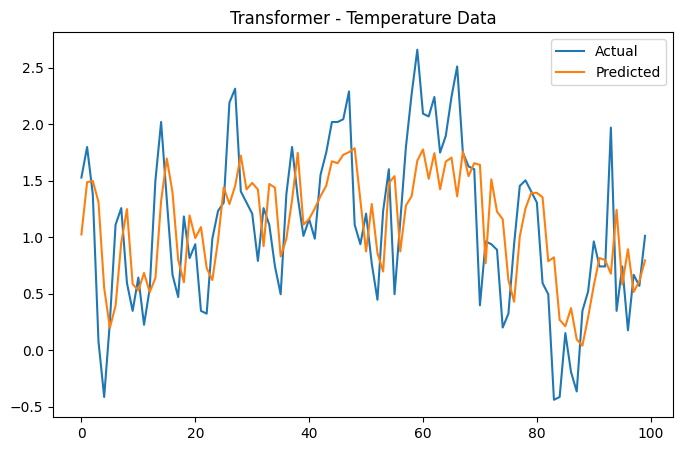

In [15]:
run_pipeline(data_temp, "Temperature Data")

## Ablation Study

In [16]:
for ws in [5, 10, 20]:
    print(f"\nWindow Size: {ws}")

    # Create sequences
    X_temp, y_temp = create_sequences(data_stock, ws, prediction_horizon)

    split = int(0.8 * len(X_temp))

    X_train = torch.tensor(X_temp[:split], dtype=torch.float32)
    y_train = torch.tensor(y_temp[:split], dtype=torch.float32).squeeze(-1)

    X_test = torch.tensor(X_temp[split:], dtype=torch.float32)
    y_test = torch.tensor(y_temp[split:], dtype=torch.float32).squeeze(-1)

    # Fix shape
    if len(X_train.shape) == 2:
        X_train = X_train.unsqueeze(-1)
        X_test = X_test.unsqueeze(-1)

    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32)

    model = CustomGRU()

    train_model(model, loader, epochs=5)

    mse, mae, rmse, _, _ = evaluate(model, X_test, y_test)

    print(f"MSE={mse:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}")


Window Size: 5
Epoch 0, Loss: 16.8727
Epoch 2, Loss: 12.6773
Epoch 4, Loss: 7.9395
MSE=0.7469, MAE=0.8383, RMSE=0.8642

Window Size: 10
Epoch 0, Loss: 22.4664
Epoch 2, Loss: 18.3141
Epoch 4, Loss: 14.0531
MSE=0.8288, MAE=0.8767, RMSE=0.9104

Window Size: 20
Epoch 0, Loss: 20.5490
Epoch 2, Loss: 16.2481
Epoch 4, Loss: 11.1281
MSE=0.6483, MAE=0.7677, RMSE=0.8052


## Ablation Study Analysis

The smallest window size (5) performed best because it focuses on recent data,
which is more relevant in volatile time-series like stock prices.

The original window size (10) performed worst, likely due to inclusion of
unnecessary past information that introduces noise.

A larger window size (20) provides more context but also increases noise,
resulting in moderate performance.

This shows that optimal window size depends on the nature of the data.

## Failure Analysis
The models struggle in regions where there are sudden changes or noise.

This happens because the models rely on past patterns and cannot handle abrupt variations effectively.

## Model Comparision
MLP ignores sequence order but still performed well in this case.

GRU and LSTM capture temporal dependencies but require proper tuning.

Transformer captures global patterns but depends on data quality.